In [ ]:
import pandas as pd
import numpy as np
from dateutil.relativedelta import relativedelta

In [ ]:
df_allergies = pd.read_csv('https://raw.githubusercontent.com/chop-analytics/analyst-take-home-task/master/datasets/allergies.csv')
df_encounters = pd.read_csv('https://raw.githubusercontent.com/chop-analytics/analyst-take-home-task/master/datasets/encounters.csv')
df_medications = pd.read_csv('https://raw.githubusercontent.com/chop-analytics/analyst-take-home-task/master/datasets/medications.csv')
df_patients = pd.read_csv('https://raw.githubusercontent.com/chop-analytics/analyst-take-home-task/master/datasets/patients.csv')
df_procedures = pd.read_csv('https://raw.githubusercontent.com/chop-analytics/analyst-take-home-task/master/datasets/procedures.csv')

# Part 1: Assemble the project cohort

The project goal is to identify patients seen for drug overdose, determine if they had an active opioid at the start of the encounter, and if they
had any readmissions for drug overdose.

Your task is to assemble the study cohort by identifying encounters that meet the following criteria:

1. The patient's visit is an encounter for drug overdose
2. The hospital encounter occurs after July 15, 1999
3. The patient's age at time of encounter is between 18 and 35 (Patient is considered to be 35 until turning 36)

In [ ]:
# I need to know how to spell the features to use them.
df_encounters.columns

Index(['Id', 'START', 'STOP', 'PATIENT', 'PROVIDER', 'ENCOUNTERCLASS', 'CODE',
       'DESCRIPTION', 'COST', 'REASONCODE', 'REASONDESCRIPTION'],
      dtype='object')

In [ ]:
# The different labels in the feature DESCRIPTION
df_encounters['DESCRIPTION'].unique()

array(['Prenatal initial visit', 'Consultation for treatment',
       'Encounter for check up (procedure)', 'Encounter for symptom',
       'Encounter for problem', 'Patient encounter procedure',
       'Hypertension follow-up encounter',
       'Periodic reevaluation and management of healthy individual (procedure)',
       'Emergency room admission (procedure)', "Encounter for 'check-up'",
       'Prenatal visit', 'Postoperative follow-up visit (procedure)',
       'Screening surveillance (regime/therapy)',
       'Gynecology service (qualifier value)',
       'Domiciliary or rest home patient evaluation and management',
       'Encounter Inpatient', 'Emergency Room Admission',
       'Urgent care clinic (procedure)',
       'Encounter for problem (procedure)',
       'Drug rehabilitation and detoxification',
       'Obstetric emergency hospital admission', 'Postnatal visit',
       'Office Visit', 'Follow-up encounter', 'Encounter for Problem',
       'Asthma follow-up', 'Inpatient 

In [ ]:
# The different labels in the feature REASONDESCRIPTION
df_encounters['REASONDESCRIPTION'].unique()

array(['Normal pregnancy', nan, 'Seasonal allergic rhinitis',
       'Acute bronchitis (disorder)', 'Viral sinusitis (disorder)',
       'Concussion with no loss of consciousness', 'Bullet wound',
       'Malignant neoplasm of breast (disorder)',
       'Osteoarthritis of knee', 'Fracture of forearm',
       'Acute viral pharyngitis (disorder)', 'Second degree burn',
       'Sinusitis (disorder)', 'Anemia (disorder)', 'Chronic pain',
       'Fracture of clavicle', 'Otitis media', 'Appendicitis',
       'Child attention deficit disorder',
       'Chronic intractable migraine without aura', 'Impacted molars',
       'Acute bacterial sinusitis (disorder)',
       'Concussion with loss of consciousness', 'Drug overdose',
       'Fracture of rib', 'Malignant tumor of colon',
       "Alzheimer's disease (disorder)", 'Hyperlipidemia', 'Cystitis',
       'Polyp of colon', 'Overlapping malignant neoplasm of colon',
       'Fetus with unknown complication',
       'Escherichia coli urinary tract

In [ ]:
# This will find any label containing the word 'drug' in the REASONDESCRIPTION feature.
for d in df_encounters['REASONDESCRIPTION'].unique():
  if isinstance(d, str) and 'drug' in d.lower():
    print(d)

Drug overdose


"Drug overdose" is in the feature "REASONDESCRIPTION"

In [ ]:
# I need to know how to spell the features to join them.
df_patients.columns

Index(['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX',
       'FIRST', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY',
       'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'ZIP'],
      dtype='object')

In [ ]:
# Joining encounters and patients to more easily filter for desired rows later on.
# Keeping all rows in encounters, because maybe the same patient visited more than once.
df_en_pa = pd.merge(df_encounters, df_patients, how='left', left_on='PATIENT', right_on='Id', suffixes=('_en', '_pa'))
print(f'shape: {df_en_pa.shape}')
df_en_pa.head()

shape: (413298, 31)


,Id_en,START,STOP,PATIENT,PROVIDER,ENCOUNTERCLASS,CODE,DESCRIPTION,COST,REASONCODE,...,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,ZIP
0,2590963f-222b-4870-b8c7-86d07f4d44b3,1959-06-18 09:43:49,1959-06-25 21:37:31,3d8e57b2-3de5-4fb6-95b4-8370270c5cc2,fa6006c2-c562-3278-859b-96b266fc3ea1,ambulatory,424441002.0,Prenatal initial visit,105.37,72892002.0,...,Bartoletti50,M,asian,asian_indian,F,Muhlenberg Pennsylvania US,372 Marks Heights Unit 20,Middle Paxton,Pennsylvania,NaN
1,ba6137e3-c8cd-42e6-9a02-eafa13d1cfa9,2008-08-29 19:14:19,2008-09-07 13:33:07,553b00b2-347c-48ec-90ee-f59924ff50eb,fe803a6f-c717-36e8-a338-9b3cdb9ee724,outpatient,698314001.0,Consultation for treatment,105.37,NaN,...,Labadie908,M,white,scottish,F,Wilkins Pennsylvania US,519 Ziemann Trail,Washington,Pennsylvania,15301.0
2,10aa7678-5c84-4ce9-81af-09272307c1f0,1999-07-12 03:05:41,1999-07-20 11:18:24,7f4ea9fb-f436-411e-ab34-e94750edfa93,cc6a930c-727f-3999-b655-179e57b30538,wellness,185349003.0,Encounter for check up (procedure),105.37,NaN,...,NaN,M,white,irish,M,Overfield Pennsylvania US,428 Strosin Fort Suite 49,Limerick,Pennsylvania,NaN
3,3710b40a-bcc0-4c0f-a204-e47a5f3aec98,1997-09-20 16:09:36,1997-09-30 22:43:32,2043c57c-1085-45a3-87e8-a223d5b6693d,d2c4dfee-3c37-318f-a415-367315d28b65,wellness,185349003.0,Encounter for check up (procedure),105.37,NaN,...,NaN,S,black,dominican,M,Wesley Saint Andrew Parish DM,580 Bechtelar Divide,Manheim,Pennsylvania,17545.0
4,92078752-a89c-4931-b95e-0f8df485e9f6,1963-09-26 09:43:49,1963-10-05 03:20:42,3d8e57b2-3de5-4fb6-95b4-8370270c5cc2,fa6006c2-c562-3278-859b-96b266fc3ea1,ambulatory,424441002.0,Prenatal initial visit,105.37,72892002.0,...,Bartoletti50,M,asian,asian_indian,F,Muhlenberg Pennsylvania US,372 Marks Heights Unit 20,Middle Paxton,Pennsylvania,NaN


In [ ]:
# I change the datatypes of the features to what they should be, to make filtering easier later on.
df_en_pa['START'] = pd.to_datetime(df_en_pa['START'])
df_en_pa['STOP'] = pd.to_datetime(df_en_pa['STOP'])
df_en_pa['BIRTHDATE'] = pd.to_datetime(df_en_pa['BIRTHDATE'])
df_en_pa['DEATHDATE'] = pd.to_datetime(df_en_pa['DEATHDATE'])

print(f'shape: {df_en_pa.shape}')
df_en_pa.head()

shape: (413298, 31)


,Id_en,START,STOP,PATIENT,PROVIDER,ENCOUNTERCLASS,CODE,DESCRIPTION,COST,REASONCODE,...,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,ZIP
0,2590963f-222b-4870-b8c7-86d07f4d44b3,1959-06-18 09:43:49,1959-06-25 21:37:31,3d8e57b2-3de5-4fb6-95b4-8370270c5cc2,fa6006c2-c562-3278-859b-96b266fc3ea1,ambulatory,424441002.0,Prenatal initial visit,105.37,72892002.0,...,Bartoletti50,M,asian,asian_indian,F,Muhlenberg Pennsylvania US,372 Marks Heights Unit 20,Middle Paxton,Pennsylvania,NaN
1,ba6137e3-c8cd-42e6-9a02-eafa13d1cfa9,2008-08-29 19:14:19,2008-09-07 13:33:07,553b00b2-347c-48ec-90ee-f59924ff50eb,fe803a6f-c717-36e8-a338-9b3cdb9ee724,outpatient,698314001.0,Consultation for treatment,105.37,NaN,...,Labadie908,M,white,scottish,F,Wilkins Pennsylvania US,519 Ziemann Trail,Washington,Pennsylvania,15301.0
2,10aa7678-5c84-4ce9-81af-09272307c1f0,1999-07-12 03:05:41,1999-07-20 11:18:24,7f4ea9fb-f436-411e-ab34-e94750edfa93,cc6a930c-727f-3999-b655-179e57b30538,wellness,185349003.0,Encounter for check up (procedure),105.37,NaN,...,NaN,M,white,irish,M,Overfield Pennsylvania US,428 Strosin Fort Suite 49,Limerick,Pennsylvania,NaN
3,3710b40a-bcc0-4c0f-a204-e47a5f3aec98,1997-09-20 16:09:36,1997-09-30 22:43:32,2043c57c-1085-45a3-87e8-a223d5b6693d,d2c4dfee-3c37-318f-a415-367315d28b65,wellness,185349003.0,Encounter for check up (procedure),105.37,NaN,...,NaN,S,black,dominican,M,Wesley Saint Andrew Parish DM,580 Bechtelar Divide,Manheim,Pennsylvania,17545.0
4,92078752-a89c-4931-b95e-0f8df485e9f6,1963-09-26 09:43:49,1963-10-05 03:20:42,3d8e57b2-3de5-4fb6-95b4-8370270c5cc2,fa6006c2-c562-3278-859b-96b266fc3ea1,ambulatory,424441002.0,Prenatal initial visit,105.37,72892002.0,...,Bartoletti50,M,asian,asian_indian,F,Muhlenberg Pennsylvania US,372 Marks Heights Unit 20,Middle Paxton,Pennsylvania,NaN


In [ ]:
# Validate datatype.
type(df_en_pa['START'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [ ]:
# Filters to meet part 1.
mask1 = (df_en_pa['REASONDESCRIPTION'] == 'Drug overdose')
mask2 = (df_en_pa['START'] > '1999-07-15')
mask3 = (df_en_pa['BIRTHDATE'] + pd.DateOffset(years=18) < df_en_pa['START']) # Ensures the patient's 18th birthday was before the encounter.
mask4 = (df_en_pa['BIRTHDATE'] + pd.DateOffset(years=36) > df_en_pa['START']) # Ensures the patient's 36th birthday is after the encounter.
df_en_pa = df_en_pa[mask1 & mask2 & mask3 & mask4]

print(f'shape: {df_en_pa.shape}')
df_en_pa.head()

shape: (431, 31)


,Id_en,START,STOP,PATIENT,PROVIDER,ENCOUNTERCLASS,CODE,DESCRIPTION,COST,REASONCODE,...,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,ZIP
373,22874b3d-0873-40e4-a455-897d51d593f7,2012-02-18 21:50:51,2012-02-28 21:12:17,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,Willms744,M,white,french,F,Adams Pennsylvania US,463 Mitchell Trace Unit 10,East Goshen,Pennsylvania,NaN
377,134c5ee3-1b72-4e3e-a44a-3efebe77603b,2013-08-03 21:50:51,2013-08-13 07:44:52,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,Willms744,M,white,french,F,Adams Pennsylvania US,463 Mitchell Trace Unit 10,East Goshen,Pennsylvania,NaN
381,6125f147-72d4-48a4-9813-2a9dc878f055,2014-12-08 21:50:51,2014-12-17 12:25:27,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,Willms744,M,white,french,F,Adams Pennsylvania US,463 Mitchell Trace Unit 10,East Goshen,Pennsylvania,NaN
390,f837dcf8-af7d-43b8-b5c2-773d494617ab,2015-08-31 21:50:51,2015-09-08 12:04:08,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,Willms744,M,white,french,F,Adams Pennsylvania US,463 Mitchell Trace Unit 10,East Goshen,Pennsylvania,NaN
3157,010594a6-a6ff-4875-9a9e-6b213367cde0,2018-12-10 00:59:35,2018-12-20 22:57:39,65b093e4-b353-447a-b9ae-290567f1c950,01246f59-4963-3c93-abf8-142e68af9e44,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,white,irish,M,Lower Heidelberg Pennsylvania US,826 Hegmann Grove Suite 14,Reading,Pennsylvania,19601.0


In [ ]:
# Proof that now there are only instances of encounters from drug overdose.
print(df_en_pa['DESCRIPTION'].unique(),'\n')

# Proof that now the age at time of encounter is a maximum of 36 years - 1 day.
print(df_en_pa[df_en_pa['START'] - df_en_pa['BIRTHDATE'] == (df_en_pa['START'] - df_en_pa['BIRTHDATE']).max()][['BIRTHDATE', 'START']], '\n')

# Proof that now the oldest encounter date is after 7-11-1999.
df_en_pa[df_en_pa['START'] == df_en_pa['START'].min()]['START']

['Emergency Room Admission'] 

        BIRTHDATE               START
326969 1966-05-29 2002-05-18 04:15:15 



,START
292519,1999-08-08 03:09:47


In [ ]:
print(f'shape: {df_en_pa.shape}\n')
df_en_pa.info()

shape: (431, 31)

<class 'pandas.core.frame.DataFrame'>
Index: 431 entries, 373 to 408533
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Id_en              431 non-null    object        
 1   START              431 non-null    datetime64[ns]
 2   STOP               431 non-null    datetime64[ns]
 3   PATIENT            431 non-null    object        
 4   PROVIDER           431 non-null    object        
 5   ENCOUNTERCLASS     431 non-null    object        
 6   CODE               431 non-null    float64       
 7   DESCRIPTION        431 non-null    object        
 8   COST               431 non-null    float64       
 9   REASONCODE         431 non-null    float64       
 10  REASONDESCRIPTION  431 non-null    object        
 11  Id_pa              431 non-null    object        
 12  BIRTHDATE          431 non-null    datetime64[ns]
 13  DEATHDATE          71 non-null     datetime64[n

# Part 2: Create additional fields

With your drug overdose encounter, create the following indicators:

1. DEATH_AT_VISIT_IND : 1 if patient died during the drug overdose encounter, e if the patient died at a different time
2. COUNT_CURRENT_MEDS : Count of active medications at the start of the drug overdose encounter
3. CURRENT_OPIOID_IND : 1 if the patient had at least one active medication at the start of the overdose encounter that is on the Opioids List
(provided below), 0 if not
4. READMISSION_90_DAY_IND : 1 if the visit resulted in a subsequent drug overdose readmission within 90 days, 0 if not
5. READMISSION_30_DAY_IND : 1 if the visit resulted in a subsequent drug overdose readmission within 30 days, 0 if not overdose encounter,
0 if not

6. FIRST_READMISSION_DATE : The date of the index visit's first readmission for drug overdose. Field should be left as N/A if no readmission for
drug overdose within 90 days

**Opioids list**
*   Hydromorphone 325Mg
*   Fentanyl – 100 MCG
*   Oxycodone-acetaminophen 100 Ml

In [ ]:
# Need to see what value represents a patient not being dead.
df_en_pa['DEATHDATE'].unique()

<DatetimeArray>
[                'NaT', '2009-08-24 00:00:00', '2009-02-26 00:00:00',
 '2009-09-01 00:00:00', '2017-08-17 00:00:00', '2017-07-24 00:00:00',
 '2011-04-09 00:00:00', '2017-04-14 00:00:00', '2013-10-20 00:00:00',
 '2010-01-03 00:00:00', '2015-08-30 00:00:00', '2018-10-25 00:00:00',
 '2008-12-01 00:00:00', '2007-04-21 00:00:00', '2003-10-17 00:00:00',
 '2018-12-16 00:00:00', '2016-03-14 00:00:00', '2001-11-10 00:00:00',
 '2011-01-11 00:00:00', '2013-09-17 00:00:00', '2000-09-13 00:00:00',
 '2013-04-27 00:00:00', '2002-10-13 00:00:00', '2015-02-02 00:00:00',
 '2014-11-20 00:00:00', '2000-03-16 00:00:00', '2008-01-30 00:00:00',
 '2012-04-21 00:00:00', '2018-07-11 00:00:00', '2016-06-16 00:00:00',
 '2014-09-17 00:00:00', '2011-06-06 00:00:00', '2010-02-17 00:00:00',
 '2010-06-06 00:00:00', '2000-08-29 00:00:00', '2013-12-25 00:00:00',
 '2001-02-24 00:00:00', '2018-07-18 00:00:00', '2019-05-10 00:00:00']
Length: 39, dtype: datetime64[ns]

In [ ]:
# 1
# I create a numpy array where each row where both conditions are True are assigned '1,' and 'e' else.
DEATH_AT_VISIT_IND = np.where((df_en_pa['DEATHDATE'] > df_en_pa['START']) & (df_en_pa['DEATHDATE'] < df_en_pa['STOP']), '1', 'e')
# Identifies the rows where the patient even died, since in the previous line, a patient who is not dead is also assigned 'e'
NOT_DEAD = np.where(pd.isnull(df_en_pa['DEATHDATE']), 'N/A', 'e')
# If DEATH_AT_VISIT_IND == 'e', replace the entry's value with NOT_DEAD, which tells us if the patient is even dead. If not, keep as is.
DEATH_AT_VISIT_IND = np.where(DEATH_AT_VISIT_IND == 'e', NOT_DEAD, DEATH_AT_VISIT_IND)
df_en_pa['DEATH_AT_VISIT_IND'] = pd.Series(DEATH_AT_VISIT_IND, index=df_en_pa.index)

print(f'shape: {df_en_pa.shape}')
df_en_pa.head()

shape: (431, 32)


,Id_en,START,STOP,PATIENT,PROVIDER,ENCOUNTERCLASS,CODE,DESCRIPTION,COST,REASONCODE,...,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,ZIP,DEATH_AT_VISIT_IND
373,22874b3d-0873-40e4-a455-897d51d593f7,2012-02-18 21:50:51,2012-02-28 21:12:17,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,M,white,french,F,Adams Pennsylvania US,463 Mitchell Trace Unit 10,East Goshen,Pennsylvania,NaN,N/A
377,134c5ee3-1b72-4e3e-a44a-3efebe77603b,2013-08-03 21:50:51,2013-08-13 07:44:52,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,M,white,french,F,Adams Pennsylvania US,463 Mitchell Trace Unit 10,East Goshen,Pennsylvania,NaN,N/A
381,6125f147-72d4-48a4-9813-2a9dc878f055,2014-12-08 21:50:51,2014-12-17 12:25:27,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,M,white,french,F,Adams Pennsylvania US,463 Mitchell Trace Unit 10,East Goshen,Pennsylvania,NaN,N/A
390,f837dcf8-af7d-43b8-b5c2-773d494617ab,2015-08-31 21:50:51,2015-09-08 12:04:08,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,M,white,french,F,Adams Pennsylvania US,463 Mitchell Trace Unit 10,East Goshen,Pennsylvania,NaN,N/A
3157,010594a6-a6ff-4875-9a9e-6b213367cde0,2018-12-10 00:59:35,2018-12-20 22:57:39,65b093e4-b353-447a-b9ae-290567f1c950,01246f59-4963-3c93-abf8-142e68af9e44,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,white,irish,M,Lower Heidelberg Pennsylvania US,826 Hegmann Grove Suite 14,Reading,Pennsylvania,19601.0,N/A


In [ ]:
# 2
# I performed a left join so that every encounter appears however many times a medication was prescribed for that encounter.
df_en_pa_me = pd.merge(df_en_pa, df_medications, how='left', left_on='Id_en', right_on='ENCOUNTER', suffixes=('_en', '_me'))

print(f'shape: {df_en_pa_me.shape}')
df_en_pa_me.head()

shape: (431, 43)


,Id_en,START_en,STOP_en,PATIENT_en,PROVIDER,ENCOUNTERCLASS,CODE_en,DESCRIPTION_en,COST_en,REASONCODE_en,...,STOP_me,PATIENT_me,ENCOUNTER,CODE_me,DESCRIPTION_me,COST_me,DISPENSES,TOTALCOST,REASONCODE_me,REASONDESCRIPTION_me
0,22874b3d-0873-40e4-a455-897d51d593f7,2012-02-18 21:50:51,2012-02-28 21:12:17,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,134c5ee3-1b72-4e3e-a44a-3efebe77603b,2013-08-03 21:50:51,2013-08-13 07:44:52,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6125f147-72d4-48a4-9813-2a9dc878f055,2014-12-08 21:50:51,2014-12-17 12:25:27,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f837dcf8-af7d-43b8-b5c2-773d494617ab,2015-08-31 21:50:51,2015-09-08 12:04:08,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,010594a6-a6ff-4875-9a9e-6b213367cde0,2018-12-10 00:59:35,2018-12-20 22:57:39,65b093e4-b353-447a-b9ae-290567f1c950,01246f59-4963-3c93-abf8-142e68af9e44,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_en_pa_me.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 43 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id_en                 431 non-null    object        
 1   START_en              431 non-null    datetime64[ns]
 2   STOP_en               431 non-null    datetime64[ns]
 3   PATIENT_en            431 non-null    object        
 4   PROVIDER              431 non-null    object        
 5   ENCOUNTERCLASS        431 non-null    object        
 6   CODE_en               431 non-null    float64       
 7   DESCRIPTION_en        431 non-null    object        
 8   COST_en               431 non-null    float64       
 9   REASONCODE_en         431 non-null    float64       
 10  REASONDESCRIPTION_en  431 non-null    object        
 11  Id_pa                 431 non-null    object        
 12  BIRTHDATE             431 non-null    datetime64[ns]
 13  DEATHDATE           

In [ ]:
# For each encounter, count the number of medications whose start date is before the start date of the encounter.
COUNT_CURRENT_MEDS = df_en_pa_me.groupby('Id_en').apply(lambda group: (group['START_me'] < group['START_en']).sum())
# I will turn the groupby object into a series, so I can just merge it with my datatable by joining on encounter Ids.
COUNT_CURRENT_MEDS = pd.Series(COUNT_CURRENT_MEDS, index=COUNT_CURRENT_MEDS.index)
COUNT_CURRENT_MEDS.name = 'COUNT_CURRENT_MEDS'

print(f'shape: {COUNT_CURRENT_MEDS.shape}')
COUNT_CURRENT_MEDS.head()

shape: (431,)


/tmp/ipython-input-3465085375.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  COUNT_CURRENT_MEDS = df_en_pa_me.groupby('Id_en').apply(lambda group: (group['START_me'] < group['START_en']).sum())


,COUNT_CURRENT_MEDS
Id_en,
0030f7f3-0070-4182-b175-0e20e7200bc9,0
00e34076-a8ac-4693-9ad7-053d60ed3320,0
010594a6-a6ff-4875-9a9e-6b213367cde0,0
0222dc3e-cfdf-4ec7-9d0d-d1918f771abe,0
026574af-ecaf-4cd5-8a60-93067c2410a4,0


In [ ]:
# Merging by joining on encounter Ids.
df_en_pa_me = pd.merge(df_en_pa_me, COUNT_CURRENT_MEDS, how='left', left_on='Id_en', right_on='Id_en', suffixes=('_en', '_2'))
df_en_pa_me.head()

,Id_en,START_en,STOP_en,PATIENT_en,PROVIDER,ENCOUNTERCLASS,CODE_en,DESCRIPTION_en,COST_en,REASONCODE_en,...,PATIENT_me,ENCOUNTER,CODE_me,DESCRIPTION_me,COST_me,DISPENSES,TOTALCOST,REASONCODE_me,REASONDESCRIPTION_me,COUNT_CURRENT_MEDS
0,22874b3d-0873-40e4-a455-897d51d593f7,2012-02-18 21:50:51,2012-02-28 21:12:17,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,134c5ee3-1b72-4e3e-a44a-3efebe77603b,2013-08-03 21:50:51,2013-08-13 07:44:52,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,6125f147-72d4-48a4-9813-2a9dc878f055,2014-12-08 21:50:51,2014-12-17 12:25:27,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,f837dcf8-af7d-43b8-b5c2-773d494617ab,2015-08-31 21:50:51,2015-09-08 12:04:08,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,010594a6-a6ff-4875-9a9e-6b213367cde0,2018-12-10 00:59:35,2018-12-20 22:57:39,65b093e4-b353-447a-b9ae-290567f1c950,01246f59-4963-3c93-abf8-142e68af9e44,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
# 3
# Checking for any medication names that might match the opioid list given.
opioids = [s for s in df_medications['DESCRIPTION'].unique() if ('Fentanyl' in s or 'Hydromorphone' in s or 'Oxycodone' in s)]
opioids

['Hydromorphone 325 MG',
 'Amlodipine 5 MG / Fentanyl 100 MCG / Olmesartan medoxomil 20 MG',
 'Abuse-Deterrent 12 HR Oxycodone Hydrochloride 15 MG Extended Release Oral Tablet',
 'Acetaminophen 325 MG / Oxycodone Hydrochloride 5 MG Oral Tablet',
 'Fentanyl 100 MCG',
 'Oxycodone-acetaminophen 100ML',
 'Fentanyl']

This list above can easily be edited to contain EXACTLY the opioid list given in the project, but I wanted to also include any drugs which the list may also be talking about.

In [ ]:
# This element is not relevant to the list.
opioids.remove('Abuse-Deterrent 12 HR Oxycodone Hydrochloride 15 MG Extended Release Oral Tablet')
opioids

['Hydromorphone 325 MG',
 'Amlodipine 5 MG / Fentanyl 100 MCG / Olmesartan medoxomil 20 MG',
 'Acetaminophen 325 MG / Oxycodone Hydrochloride 5 MG Oral Tablet',
 'Fentanyl 100 MCG',
 'Oxycodone-acetaminophen 100ML',
 'Fentanyl']

In [ ]:
# For each group, checks if any row in the group has a value in 'DESCRIPTION_me' contained in the opioid list, then turns False entries into 0s and True ones into 1s.
CURRENT_OPIOID_IND = df_en_pa_me.groupby('Id_en').apply(lambda group: int(group['DESCRIPTION_me'].isin(opioids).any()))
# I will turn the groupby object into a series, so I can just merge it with my datatable by joining on encounter Ids.
CURRENT_OPIOID_IND = pd.Series(CURRENT_OPIOID_IND, index=CURRENT_OPIOID_IND.index)
CURRENT_OPIOID_IND.name = 'CURRENT_OPIOID_IND'

print(f'shape: {CURRENT_OPIOID_IND.shape}')
CURRENT_OPIOID_IND

shape: (431,)


/tmp/ipython-input-3010324564.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  CURRENT_OPIOID_IND = df_en_pa_me.groupby('Id_en').apply(lambda group: int(group['DESCRIPTION_me'].isin(opioids).any()))


,CURRENT_OPIOID_IND
Id_en,
0030f7f3-0070-4182-b175-0e20e7200bc9,0
00e34076-a8ac-4693-9ad7-053d60ed3320,0
010594a6-a6ff-4875-9a9e-6b213367cde0,0
0222dc3e-cfdf-4ec7-9d0d-d1918f771abe,0
026574af-ecaf-4cd5-8a60-93067c2410a4,0
...,...
fcca13ea-affd-4ec1-b03d-87a98cacb53a,0
fd291fc1-8263-41c2-bb16-31bcb645cdd9,0
fed084a3-c33a-476e-a4d6-47865117653f,0


In [ ]:
# Merging by joining on encounter Ids.
df_en_pa_me = pd.merge(df_en_pa_me, CURRENT_OPIOID_IND, how='left', left_on='Id_en', right_on='Id_en', suffixes=('_en', '_3'))
df_en_pa_me.head()

,Id_en,START_en,STOP_en,PATIENT_en,PROVIDER,ENCOUNTERCLASS,CODE_en,DESCRIPTION_en,COST_en,REASONCODE_en,...,ENCOUNTER,CODE_me,DESCRIPTION_me,COST_me,DISPENSES,TOTALCOST,REASONCODE_me,REASONDESCRIPTION_me,COUNT_CURRENT_MEDS,CURRENT_OPIOID_IND
0,22874b3d-0873-40e4-a455-897d51d593f7,2012-02-18 21:50:51,2012-02-28 21:12:17,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,134c5ee3-1b72-4e3e-a44a-3efebe77603b,2013-08-03 21:50:51,2013-08-13 07:44:52,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,6125f147-72d4-48a4-9813-2a9dc878f055,2014-12-08 21:50:51,2014-12-17 12:25:27,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,f837dcf8-af7d-43b8-b5c2-773d494617ab,2015-08-31 21:50:51,2015-09-08 12:04:08,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,010594a6-a6ff-4875-9a9e-6b213367cde0,2018-12-10 00:59:35,2018-12-20 22:57:39,65b093e4-b353-447a-b9ae-290567f1c950,01246f59-4963-3c93-abf8-142e68af9e44,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [ ]:
# 4
"""
Given an encounter id, this function grabs the encounters (rows) of the
datatable which meet the conditions:
  a) the encounter has the same patient as the given encounter
  b) the encounter's start date is after the given encounter's stop date
  c) the encounter's start date is within 90 (by default) days of the given
  encounter's end date
  d) the encounter is for drug overdose
  e) the encounter is not the given encounter itself

The function then identifies if the resulting encounters create a sub-datatable
which is empty or not. It does this by analyzing whether the first coordinate of
the shape of the sub-datatable (the rows) is 0 (no encounters meet all the
conditions) or greater than 0 (there are encounters meeting all the conditions).
"""
def readmission(id, days=90):
  curr_patient = df_en_pa_me[df_en_pa_me['Id_en'] == id]['PATIENT_en'].iloc[0]
  curr_stop_en = df_en_pa_me[df_en_pa_me['Id_en'] == id]['STOP_en'].iloc[0]

  return int(df_en_pa_me[
      (df_en_pa_me['PATIENT_en'] == curr_patient) &
      (df_en_pa_me['START_en'] > curr_stop_en) &
      (df_en_pa_me['START_en'] - curr_stop_en <= pd.Timedelta(days=days)) &
      (df_en_pa_me['DESCRIPTION_en'] == 'Drug rehabilitation and detoxification') &
      (df_en_pa_me['Id_en'] != id)
  ].shape[0] > 0)

df_en_pa_me['READMISSION_90_DAY_IND'] = df_en_pa_me['Id_en'].apply(readmission)
df_en_pa_me.head()

,Id_en,START_en,STOP_en,PATIENT_en,PROVIDER,ENCOUNTERCLASS,CODE_en,DESCRIPTION_en,COST_en,REASONCODE_en,...,CODE_me,DESCRIPTION_me,COST_me,DISPENSES,TOTALCOST,REASONCODE_me,REASONDESCRIPTION_me,COUNT_CURRENT_MEDS,CURRENT_OPIOID_IND,READMISSION_90_DAY_IND
0,22874b3d-0873-40e4-a455-897d51d593f7,2012-02-18 21:50:51,2012-02-28 21:12:17,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
1,134c5ee3-1b72-4e3e-a44a-3efebe77603b,2013-08-03 21:50:51,2013-08-13 07:44:52,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
2,6125f147-72d4-48a4-9813-2a9dc878f055,2014-12-08 21:50:51,2014-12-17 12:25:27,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
3,f837dcf8-af7d-43b8-b5c2-773d494617ab,2015-08-31 21:50:51,2015-09-08 12:04:08,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
4,010594a6-a6ff-4875-9a9e-6b213367cde0,2018-12-10 00:59:35,2018-12-20 22:57:39,65b093e4-b353-447a-b9ae-290567f1c950,01246f59-4963-3c93-abf8-142e68af9e44,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0


In [ ]:
# 5
# I apply the same function I defined before, but with 30 days instead.
df_en_pa_me['READMISSION_30_DAY_IND'] = df_en_pa_me['Id_en'].apply(lambda id: readmission(id, days=30))
df_en_pa_me.head()

,Id_en,START_en,STOP_en,PATIENT_en,PROVIDER,ENCOUNTERCLASS,CODE_en,DESCRIPTION_en,COST_en,REASONCODE_en,...,DESCRIPTION_me,COST_me,DISPENSES,TOTALCOST,REASONCODE_me,REASONDESCRIPTION_me,COUNT_CURRENT_MEDS,CURRENT_OPIOID_IND,READMISSION_90_DAY_IND,READMISSION_30_DAY_IND
0,22874b3d-0873-40e4-a455-897d51d593f7,2012-02-18 21:50:51,2012-02-28 21:12:17,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
1,134c5ee3-1b72-4e3e-a44a-3efebe77603b,2013-08-03 21:50:51,2013-08-13 07:44:52,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
2,6125f147-72d4-48a4-9813-2a9dc878f055,2014-12-08 21:50:51,2014-12-17 12:25:27,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
3,f837dcf8-af7d-43b8-b5c2-773d494617ab,2015-08-31 21:50:51,2015-09-08 12:04:08,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
4,010594a6-a6ff-4875-9a9e-6b213367cde0,2018-12-10 00:59:35,2018-12-20 22:57:39,65b093e4-b353-447a-b9ae-290567f1c950,01246f59-4963-3c93-abf8-142e68af9e44,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0


In [ ]:
# 6
# Creates a subtable of the start dates of all rows where 'READMISSION_90_DAY_IND' was marked 1.
resulted_in_readmitted = df_en_pa_me[df_en_pa_me['READMISSION_90_DAY_IND'] == 1]

"""
Works similar to the readmission function, but this one returns the the first
reencounter date after obtaining the subtable of reeencounters given an
encounter id.
"""
def first_reencounter(id, days=90):
  curr_patient = df_en_pa_me[df_en_pa_me['Id_en'] == id]['PATIENT_en'].iloc[0]
  curr_stop_en = df_en_pa_me[df_en_pa_me['Id_en'] == id]['STOP_en'].iloc[0]

  return df_en_pa_me[
      (df_en_pa_me['PATIENT_en'] == curr_patient) &
      (df_en_pa_me['START_en'] > curr_stop_en) &
      (df_en_pa_me['START_en'] - curr_stop_en <= pd.Timedelta(days=days)) &
      (df_en_pa_me['DESCRIPTION_en'] == 'Drug rehabilitation and detoxification') &
      (df_en_pa_me['Id_en'] != id)
      ]['START_en'].min()

FIRST_READMISSION_DATE = resulted_in_readmitted['Id_en'].apply(first_reencounter)
FIRST_READMISSION_DATE.name = 'FIRST_READMISSION_DATE'

print(f'shape: {FIRST_READMISSION_DATE.shape}')
FIRST_READMISSION_DATE

shape: (0,)


,FIRST_READMISSION_DATE


In [ ]:
# Joining on the indeces of both tables.
df_en_pa_me = pd.merge(df_en_pa_me, FIRST_READMISSION_DATE, how='left', left_index=True, right_index=True, suffixes=('_en', '_6'))
df_en_pa_me

,Id_en,START_en,STOP_en,PATIENT_en,PROVIDER,ENCOUNTERCLASS,CODE_en,DESCRIPTION_en,COST_en,REASONCODE_en,...,COST_me,DISPENSES,TOTALCOST,REASONCODE_me,REASONDESCRIPTION_me,COUNT_CURRENT_MEDS,CURRENT_OPIOID_IND,READMISSION_90_DAY_IND,READMISSION_30_DAY_IND,FIRST_READMISSION_DATE
0,22874b3d-0873-40e4-a455-897d51d593f7,2012-02-18 21:50:51,2012-02-28 21:12:17,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN
1,134c5ee3-1b72-4e3e-a44a-3efebe77603b,2013-08-03 21:50:51,2013-08-13 07:44:52,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN
2,6125f147-72d4-48a4-9813-2a9dc878f055,2014-12-08 21:50:51,2014-12-17 12:25:27,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN
3,f837dcf8-af7d-43b8-b5c2-773d494617ab,2015-08-31 21:50:51,2015-09-08 12:04:08,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN
4,010594a6-a6ff-4875-9a9e-6b213367cde0,2018-12-10 00:59:35,2018-12-20 22:57:39,65b093e4-b353-447a-b9ae-290567f1c950,01246f59-4963-3c93-abf8-142e68af9e44,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,09512352-7f84-4960-85be-9325aa91c023,2006-03-03 00:54:04,2006-03-08 06:12:14,12842850-ab85-4655-92e1-f8c5f1ac5cc2,a95900fc-145a-3255-b7a6-92315fc1f076,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN
427,13459d81-c8e0-44ba-915f-b3cc7a32c118,2017-04-20 00:54:04,2017-04-30 09:28:08,12842850-ab85-4655-92e1-f8c5f1ac5cc2,a95900fc-145a-3255-b7a6-92315fc1f076,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN
428,454afa58-c029-463e-8722-d795f1383150,2009-07-21 14:36:02,2009-07-29 02:22:25,5849b818-b6b3-4ed5-b3be-19d2f6fc2aa6,fe803a6f-c717-36e8-a338-9b3cdb9ee724,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN
429,29d0cb49-6a58-41e4-8ddd-d081eb0559ee,2018-08-03 22:14:33,2018-08-16 08:04:15,1e34d181-4497-4649-8fd3-b7e7f23109d2,031dc37f-ebac-3924-9872-29d56127dbc2,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN


In [ ]:
# Verifying it worked
df_en_pa_me.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 48 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Id_en                   431 non-null    object        
 1   START_en                431 non-null    datetime64[ns]
 2   STOP_en                 431 non-null    datetime64[ns]
 3   PATIENT_en              431 non-null    object        
 4   PROVIDER                431 non-null    object        
 5   ENCOUNTERCLASS          431 non-null    object        
 6   CODE_en                 431 non-null    float64       
 7   DESCRIPTION_en          431 non-null    object        
 8   COST_en                 431 non-null    float64       
 9   REASONCODE_en           431 non-null    float64       
 10  REASONDESCRIPTION_en    431 non-null    object        
 11  Id_pa                   431 non-null    object        
 12  BIRTHDATE               431 non-null    datetime64

In [ ]:
# Verifying it worked
df_en_pa_me.iloc[80]

,80
Id_en,09e9d57d-2115-422c-9df3-2d7f79c20bec
START_en,2015-05-14 19:07:39
STOP_en,2015-05-23 07:46:15
PATIENT_en,67ccb671-4f0d-45c0-83cc-ccf0881fc00c
PROVIDER,f852c05a-c2e8-34cb-9b01-ac62b2385214
ENCOUNTERCLASS,emergency
CODE_en,50849002.0
DESCRIPTION_en,Emergency Room Admission
COST_en,105.37
REASONCODE_en,55680006.0


In [ ]:
# Will replace all 'NaT' values with 'N/A'
df_en_pa_me['FIRST_READMISSION_DATE'] = df_en_pa_me['FIRST_READMISSION_DATE'].apply(lambda x: 'N/A' if pd.isnull(x) else x)
df_en_pa_me.head()

,Id_en,START_en,STOP_en,PATIENT_en,PROVIDER,ENCOUNTERCLASS,CODE_en,DESCRIPTION_en,COST_en,REASONCODE_en,...,COST_me,DISPENSES,TOTALCOST,REASONCODE_me,REASONDESCRIPTION_me,COUNT_CURRENT_MEDS,CURRENT_OPIOID_IND,READMISSION_90_DAY_IND,READMISSION_30_DAY_IND,FIRST_READMISSION_DATE
0,22874b3d-0873-40e4-a455-897d51d593f7,2012-02-18 21:50:51,2012-02-28 21:12:17,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,N/A
1,134c5ee3-1b72-4e3e-a44a-3efebe77603b,2013-08-03 21:50:51,2013-08-13 07:44:52,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,N/A
2,6125f147-72d4-48a4-9813-2a9dc878f055,2014-12-08 21:50:51,2014-12-17 12:25:27,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,N/A
3,f837dcf8-af7d-43b8-b5c2-773d494617ab,2015-08-31 21:50:51,2015-09-08 12:04:08,708b81c9-21a9-411a-aae4-052ef8925b97,fb37c581-84a6-3513-9b1e-1d55e67e887a,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,N/A
4,010594a6-a6ff-4875-9a9e-6b213367cde0,2018-12-10 00:59:35,2018-12-20 22:57:39,65b093e4-b353-447a-b9ae-290567f1c950,01246f59-4963-3c93-abf8-142e68af9e44,emergency,50849002.0,Emergency Room Admission,105.37,55680006.0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,N/A


# Part 3: Export the data to a CSV file

Export a dataset containing these required fields:

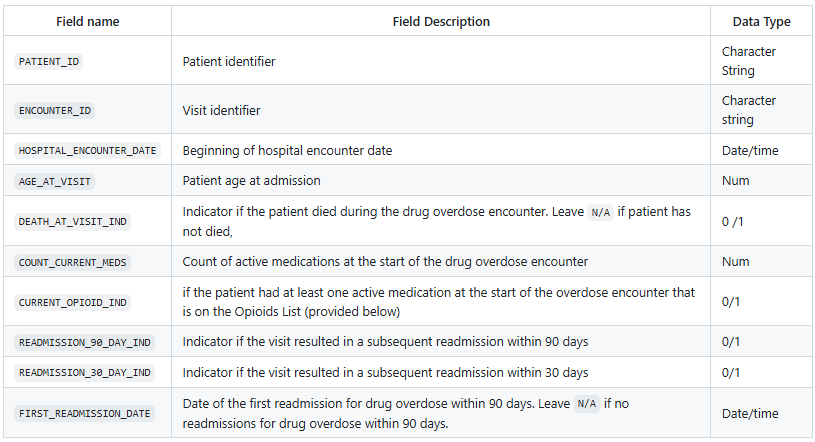

In [ ]:
# Need to know names of columns to rename them.
df_en_pa_me.columns

Index(['Id_en', 'START_en', 'STOP_en', 'PATIENT_en', 'PROVIDER',
       'ENCOUNTERCLASS', 'CODE_en', 'DESCRIPTION_en', 'COST_en',
       'REASONCODE_en', 'REASONDESCRIPTION_en', 'Id_pa', 'BIRTHDATE',
       'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX', 'FIRST', 'LAST',
       'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER',
       'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'ZIP', 'DEATH_AT_VISIT_IND',
       'START_me', 'STOP_me', 'PATIENT_me', 'ENCOUNTER', 'CODE_me',
       'DESCRIPTION_me', 'COST_me', 'DISPENSES', 'TOTALCOST', 'REASONCODE_me',
       'REASONDESCRIPTION_me', 'COUNT_CURRENT_MEDS', 'CURRENT_OPIOID_IND',
       'READMISSION_90_DAY_IND', 'READMISSION_30_DAY_IND',
       'FIRST_READMISSION_DATE'],
      dtype='object')

In [ ]:
df_final = df_en_pa_me.rename(columns={
    'PATIENT_en': 'PATIENT_ID',
    'Id_en': 'ENCOUNTER_ID',
    'START_en': 'HOSPITAL_ENCOUNTER_DATE',
    'BIRTHDATE': 'AGE_AT_VISIT'
    })
df_final = df_final[['PATIENT_ID', 'ENCOUNTER_ID', 'HOSPITAL_ENCOUNTER_DATE',
                     'AGE_AT_VISIT', 'DEATH_AT_VISIT_IND', 'COUNT_CURRENT_MEDS',
                     'CURRENT_OPIOID_IND', 'READMISSION_90_DAY_IND',
                     'READMISSION_30_DAY_IND', 'FIRST_READMISSION_DATE']]
# Making AGE_AT_VISIT actually the patient's age at the start of the encounter, instead of their birthdate.
df_final['AGE_AT_VISIT'] = df_final.apply(lambda row: relativedelta(row['HOSPITAL_ENCOUNTER_DATE'], row['AGE_AT_VISIT']).years, axis=1)

# Ensuring correct data types one more time, just in case.
df_final['PATIENT_ID'] = df_final['PATIENT_ID'].astype(str)
df_final['ENCOUNTER_ID'] = df_final['ENCOUNTER_ID'].astype(str)
df_final['HOSPITAL_ENCOUNTER_DATE'] = df_final['HOSPITAL_ENCOUNTER_DATE'].astype('datetime64[ns]', errors='ignore')
df_final['FIRST_READMISSION_DATE'] = df_final['FIRST_READMISSION_DATE'].astype('datetime64[ns]', errors='ignore')
df_final.head()

,PATIENT_ID,ENCOUNTER_ID,HOSPITAL_ENCOUNTER_DATE,AGE_AT_VISIT,DEATH_AT_VISIT_IND,COUNT_CURRENT_MEDS,CURRENT_OPIOID_IND,READMISSION_90_DAY_IND,READMISSION_30_DAY_IND,FIRST_READMISSION_DATE
0,708b81c9-21a9-411a-aae4-052ef8925b97,22874b3d-0873-40e4-a455-897d51d593f7,2012-02-18 21:50:51,25,N/A,0,0,0,0,N/A
1,708b81c9-21a9-411a-aae4-052ef8925b97,134c5ee3-1b72-4e3e-a44a-3efebe77603b,2013-08-03 21:50:51,26,N/A,0,0,0,0,N/A
2,708b81c9-21a9-411a-aae4-052ef8925b97,6125f147-72d4-48a4-9813-2a9dc878f055,2014-12-08 21:50:51,28,N/A,0,0,0,0,N/A
3,708b81c9-21a9-411a-aae4-052ef8925b97,f837dcf8-af7d-43b8-b5c2-773d494617ab,2015-08-31 21:50:51,28,N/A,0,0,0,0,N/A
4,65b093e4-b353-447a-b9ae-290567f1c950,010594a6-a6ff-4875-9a9e-6b213367cde0,2018-12-10 00:59:35,23,N/A,0,0,0,0,N/A


In [ ]:
df_final.to_csv('ARON_SILBERWASSER.csv', index=False)